# A practical playbook #

This notebook is structured as a practical guide. In today's highly competitive culinary landscape, data-driven decision-making is paramount for the success of any food business. This Kaggle project embarks on a comprehensive analysis of operational data from a restaurant or similar food establishment. The primary objective is to unearth actionable insights that can inform robust business strategies, moving beyond traditional intuition to a more precise, evidence-based approach.

This analysis delves into key operational facets, including the performance of individual menu items, nuanced customer behavior patterns, identification of peak operating hours, and the determination of the most profitable products. By illuminating these critical areas, this project aims to empower businesses to implement concrete strategies designed to optimize costs, maximize revenue, and ultimately enhance customer satisfaction.

# Project Objectives #

### Product Portfolio Analysis ###
Identify top-performing items that drive the highest sales and revenue, while also highlighting underperforming products. This analysis will support data-driven decisions for menu refinement and product positioning.

### Operational Performance Optimization ###
Examine order and revenue patterns across different days and hours to uncover peak business periods. These insights can guide workforce allocation and inventory planning to improve efficiency and reduce costs.

### Customer & Market Insights ###
Explore customer preferences across product categories and payment methods to inform targeted sales and marketing initiatives. This includes strategies such as promoting underutilized items or offering time-specific promotions to boost engagement.

### Strategic Impact ###
Transform raw business data into actionable insights that enhance profitability, streamline operations, and strengthen overall business performance.

## Data Loading ##

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter
import seaborn as sns

colors = {
    "white_1": "#ffffff",
    "white_2": "#fefefe",
    "dark_blue": "#0d2c41",
    "accent_blue": "#0f8de2"
}

import warnings 
warnings.filterwarnings('ignore')

df = pd.read_csv("/kaggle/input/restaurant-orders/restaurant_orders.csv")
df.head()

,Order ID,Customer Name,Food Item,Category,Quantity,Price,Payment Method,Order Time
0,2268,Mary Vega DDS,Pasta,Main,5,16.52,Cash,2025-02-02 14:28:41
1,3082,Brandon Myers,Brownie,Dessert,4,17.27,Debit Card,2025-06-08 10:57:47
2,3160,Margaret Wells,Pasta,Main,1,3.37,Credit Card,2025-03-04 07:41:41
3,1272,Michael Matthews,Pasta,Main,5,2.20,Online Payment,2025-05-15 12:43:45
4,9447,Connor Williams,Soup,Starter,1,12.23,Cash,2025-03-15 14:25:56


The dataset sample above captures individual food orders, including details on the customer, product purchased, and transaction specifics. Each row represents a unique order identified by an Order ID.

In [2]:
df.shape

(500, 8)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        500 non-null    int64  
 1   Customer Name   500 non-null    object 
 2   Food Item       500 non-null    object 
 3   Category        500 non-null    object 
 4   Quantity        500 non-null    int64  
 5   Price           500 non-null    float64
 6   Payment Method  500 non-null    object 
 7   Order Time      500 non-null    object 
dtypes: float64(1), int64(2), object(5)
memory usage: 31.4+ KB


In [4]:
df.describe(). T

,count,mean,std,min,25%,50%,75%,max
Order ID,500.0,5683.29600,2599.688068,1055.00,3342.00,5762.000,7945.00,9997.00
Quantity,500.0,3.03000,1.474261,1.00,2.00,3.000,4.00,5.00
Price,500.0,13.19718,6.685852,2.06,7.28,13.305,19.08,24.99


In [5]:
df.isna(). sum()
df.isna(). mean() * 100

Order ID          0.0
Customer Name     0.0
Food Item         0.0
Category          0.0
Quantity          0.0
Price             0.0
Payment Method    0.0
Order Time        0.0
dtype: float64

In [6]:
df['Order Time'] = pd.to_datetime(df['Order Time'])

df['Year'] = df['Order Time'].dt.year
df['Month'] = df['Order Time'].dt.month
df['Day'] = df['Order Time'].dt.day
df['Hour'] = df['Order Time'].dt.hour
df["Month Name"] = df["Order Time"].dt.strftime("%b")
df["Day Name"] = df["Order Time"].dt.day_name()
df["Income"] = df["Quantity"] * df["Price"]


conditions = [
    (df['Hour'] >= 5) & (df['Hour'] < 11), 
    (df['Hour'] >= 11) & (df['Hour'] < 16), 
    (df['Hour'] >= 16) & (df['Hour'] < 22)  
]
choices = [
    'Breakfast',
    'Lunch',
    'Dinner'
]

df['Meal Time'] = np.select(conditions, choices, default='Late Night')

def currency(x, pos):
    return f"${x:,.0f}"

In [7]:
df.head()

,Order ID,Customer Name,Food Item,Category,Quantity,Price,Payment Method,Order Time,Year,Month,Day,Hour,Month Name,Day Name,Income,Meal Time
0,2268,Mary Vega DDS,Pasta,Main,5,16.52,Cash,2025-02-02 14:28:41,2025,2,2,14,Feb,Sunday,82.60,Lunch
1,3082,Brandon Myers,Brownie,Dessert,4,17.27,Debit Card,2025-06-08 10:57:47,2025,6,8,10,Jun,Sunday,69.08,Breakfast
2,3160,Margaret Wells,Pasta,Main,1,3.37,Credit Card,2025-03-04 07:41:41,2025,3,4,7,Mar,Tuesday,3.37,Breakfast
3,1272,Michael Matthews,Pasta,Main,5,2.20,Online Payment,2025-05-15 12:43:45,2025,5,15,12,May,Thursday,11.00,Lunch
4,9447,Connor Williams,Soup,Starter,1,12.23,Cash,2025-03-15 14:25:56,2025,3,15,14,Mar,Saturday,12.23,Lunch


In [8]:
df.columns

Index(['Order ID', 'Customer Name', 'Food Item', 'Category', 'Quantity',
       'Price', 'Payment Method', 'Order Time', 'Year', 'Month', 'Day', 'Hour',
       'Month Name', 'Day Name', 'Income', 'Meal Time'],
      dtype='object')

**Order ID:** A distinct, immutable identifier assigned to each individual customer order, ensuring unique traceability and reference.

**Customer Name:** The full name of the customer responsible for placing the order, facilitating customer segmentation and personalized analysis.

**Food Item:** The specific food or beverage product selected by the customer within an order, providing granular detail on consumption patterns.

**Category:** A high-level classification denoting the type of food item (e.g., 'Main Course', 'Dessert', 'Appetizer'), crucial for menu analysis and strategic planning.

**Quantity:** The numerical count of units for a particular food item included within a single order, essential for calculating total item sales and inventory management.

**Price:** The standardized monetary value assigned to a single unit of the food item, forming the basis for revenue calculations.

**Payment Method:** The financial instrument or method utilized by the customer to complete the transaction (e.g., 'Cash', 'Debit Card', 'Credit Card'), offering insights into customer payment preferences and financial operations.

**Order Time:** The precise timestamp, including both date and hour, when the order was officially placed, enabling temporal analysis of sales trends.

**Year:** The calendar year in which the order was placed, providing a yearly aggregation point for long-term trend analysis.

**Month:** The numerical representation of the month an order was placed (e.g., '1' for January, '12' for December), allowing for seasonal analysis.

**Day:** The day of the month on which the order was placed, useful for intra-month pattern identification.

**Month Name:** The full categorical name of the month (e.g., 'January', 'February'), enhancing readability and interpretability for seasonal reporting.

**Day Name:** The full categorical name of the day of the week (e.g., 'Monday', 'Tuesday'), vital for understanding weekly sales cycles and operational planning.

**Income:** The total revenue generated from a specific food item within an order, calculated as the product of 'Quantity' and 'Price', representing the direct financial contribution of that item.

**Meal Time:** A categorized temporal segment of the day (e.g., 'Breakfast', 'Lunch', 'Dinner'), allowing for analysis of sales performance and customer behavior during traditional meal periods.


# Leading Menu Items by Total Units Sold #

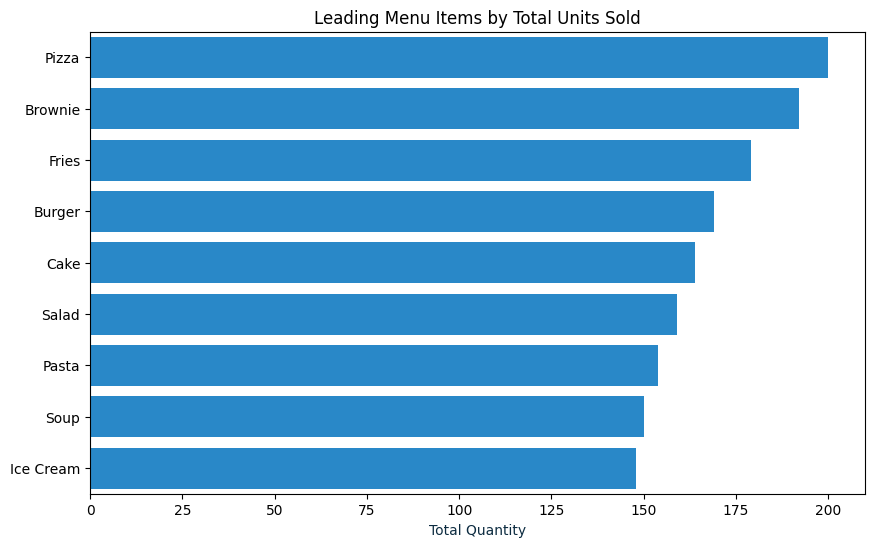

In [9]:
top_items = df.groupby("Food Item")["Quantity"].sum().sort_values(ascending=False).head(15)
plt.figure(figsize=(10,6))
sns.barplot(x=top_items.values, y=top_items.index, color=colors["accent_blue"])
plt.title("Leading Menu Items by Total Units Sold",)
plt.xlabel("Total Quantity", color=colors["dark_blue"])
plt.ylabel("")
plt.show()

This horizontal bar chart ranks the top-selling food items by total quantity sold, providing a clear visual of customer preferences. Pizza stands out as the most popular menu item, with an impressive sales total of 200 units—significantly outpacing all other offerings. The remaining items show lower and relatively similar sales quantities, illustrating a distinct preference hierarchy. This chart effectively highlights the most favored dishes, offering valuable insights for menu optimization, inventory management, and targeted marketing efforts to enhance overall sales performance and customer satisfaction.

# Monthly Revenue Trends #

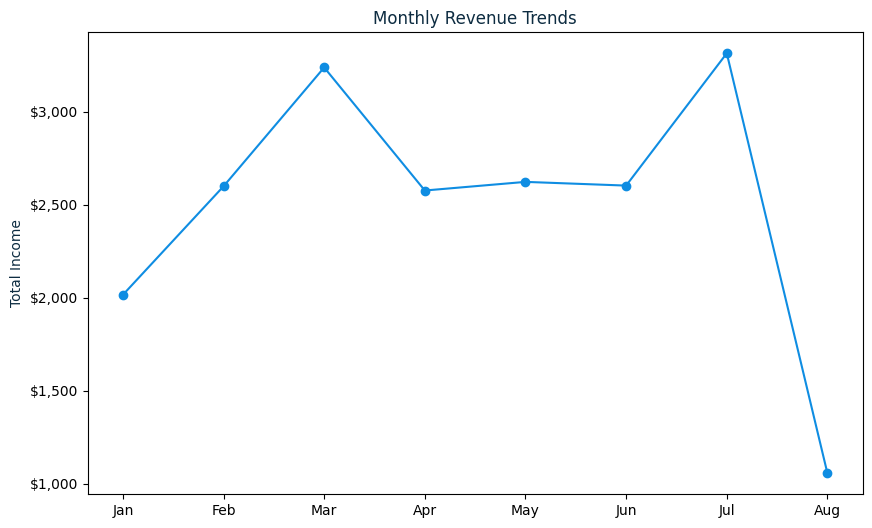

In [10]:
income_month = df.groupby(["Year","Month","Month Name"])["Income"].sum().reset_index()
income_month = income_month.sort_values(["Year","Month"])
plt.figure(figsize=(10,6))
plt.plot(income_month["Month Name"], income_month["Income"], marker="o", color=colors["accent_blue"])
plt.title("Monthly Revenue Trends", color=colors["dark_blue"])
plt.ylabel("Total Income", color=colors["dark_blue"])
plt.gca().yaxis.set_major_formatter(FuncFormatter(currency))
plt.show()

This line graph presents the total monthly income trends over the observed period. The data reveals two prominent peaks in revenue, occurring in March and July, with respective earnings of $3,237 and $3,314. These months represent the restaurant’s most profitable periods. However, the graph also highlights a sharp and notable decline in income in August, dropping to a low of $1,057. This visualization effectively captures the business’s fluctuating financial performance over time, underscoring critical periods of both strong revenue generation and sudden downturns. Such insights are essential for identifying seasonality, planning resource allocation, and implementing strategies to stabilize income.

# Revenue Breakdown by Food Category #

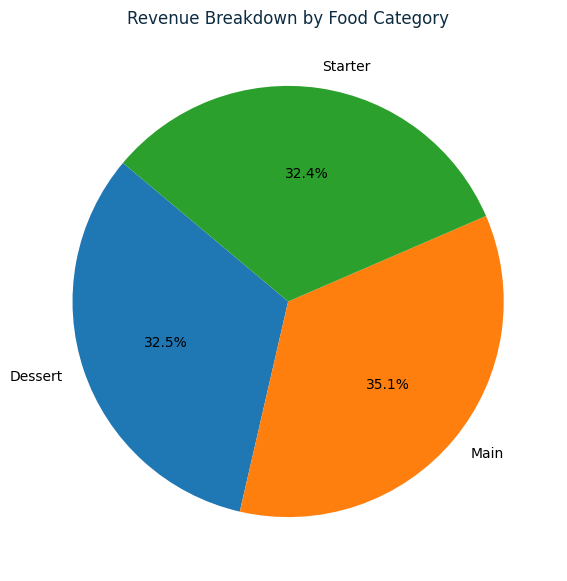

In [11]:
income_cat = df.groupby("Category")["Income"].sum()
plt.figure(figsize=(7,7))
plt.pie(income_cat, labels=income_cat.index, autopct="%1.1f%%", startangle=140)
plt.title("Revenue Breakdown by Food Category", color=colors["dark_blue"])
plt.show()


This chart depicts the distribution of total income across the restaurant’s food categories. The "Main" course category leads revenue generation, contributing 35.1% of the overall income. The "Dessert" and "Starter" categories follow closely, accounting for 32.5% and 32.4% respectively, indicating a near-equivalent contribution. This distribution reveals that while main courses form the primary revenue driver, desserts and starters play an almost equally significant role in the business’s income stream. Understanding this balance is crucial for optimizing menu design, inventory management, and targeted promotional strategies to maximize overall profitability.

# Order Volume by Hour #

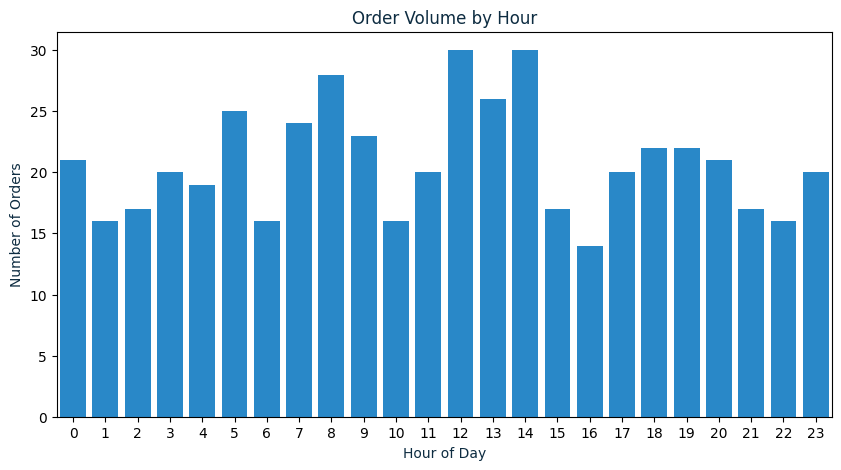

In [12]:
hourly = df.groupby("Hour")["Order ID"].count()
plt.figure(figsize=(10,5))
sns.barplot(x=hourly.index, y=hourly.values, color=colors["accent_blue"])
plt.title("Order Volume by Hour", color=colors["dark_blue"])
plt.xlabel("Hour of Day", color=colors["dark_blue"])
plt.ylabel("Number of Orders", color=colors["dark_blue"])
plt.show()

This line graph illustrates the distribution of total order counts by hour throughout the day. The data shows distinct peaks at 5:00 AM, 12:00 PM, and 2:00 PM, with the highest order count reaching 30 at both 12:00 PM and 2:00 PM. These peak hours indicate periods of heightened activity, reflecting intense business during the lunch and early afternoon times. Order volumes remain steady around 22 in the evening, suggesting consistent customer engagement, while significantly declining during the night and early morning hours. This temporal pattern offers valuable insight into daily customer demand cycles, informing staffing, inventory, and operational planning to optimize efficiency during busy and slow periods.

# Weekly Revenue Distribution #



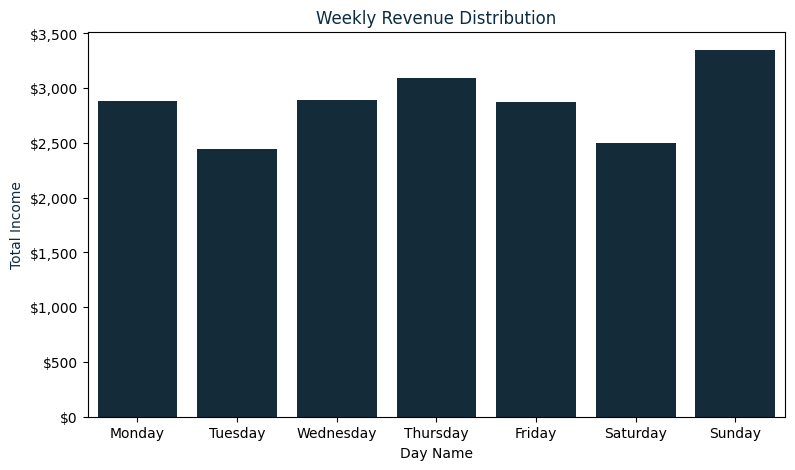

In [13]:
dow = df.groupby("Day Name")["Income"].sum().reindex(
    ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
)
plt.figure(figsize=(9,5))
sns.barplot(x=dow.index, y=dow.values, color=colors["dark_blue"])
plt.title("Weekly Revenue Distribution", color=colors["dark_blue"])
plt.ylabel("Total Income", color=colors["dark_blue"])
plt.gca().yaxis.set_major_formatter(FuncFormatter(currency))
plt.show()


This chart presents the total income generated by the business across different days of the week, highlighting distinct patterns in daily revenue. Sunday emerges as the peak earning day, significantly outperforming all other days in terms of income. Midweek days, specifically Wednesday and Thursday, also contribute substantial revenue, reflecting consistent business activity. Conversely, Tuesday and Saturday register the lowest income levels, with Saturday's performance being particularly noteworthy as it diverges from typical weekend sales trends by producing less revenue compared to other days. This insight underscores potential opportunities to investigate factors influencing weekend performance, such as customer behavior or operational adjustments, and suggests targeted strategies to enhance income on lower-performing days while capitalizing on high-revenue periods.

# Revenue Patterns by Day and Hour #

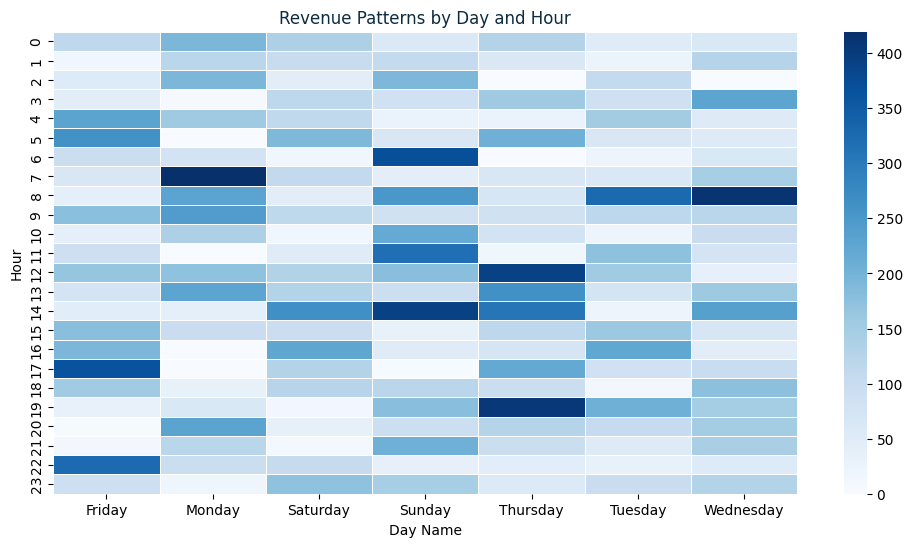

In [14]:
pivot = df.pivot_table(index="Hour", columns="Day Name", values="Income", aggfunc="sum", fill_value=0)
plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="Blues", linewidths=0.5)
plt.title("Revenue Patterns by Day and Hour", color=colors["dark_blue"])
plt.show()

This heatmap visualizes the total income generated by the business, segmented by day of the week and hour of the day. The intensity of the red color correlates with income levels, where darker shades indicate higher revenue and lighter shades represent lower earnings. Notably, the highest income "hot zones" appear during weekend afternoons and evenings, highlighting key profitable periods. Additionally, significant income peaks are evident on Monday morning at 8:00 AM ($419) and Sunday morning at 9:00 AM ($410), signaling strong early-day business activity on these days. Consistently, lunch hours (12:00 PM to 2:00 PM) stand out as some of the busiest and most lucrative across the entire week. These insights provide valuable guidance for optimizing staffing, inventory, and promotional efforts to maximize profitability during peak income intervals.

# Meal Time Product Composition #

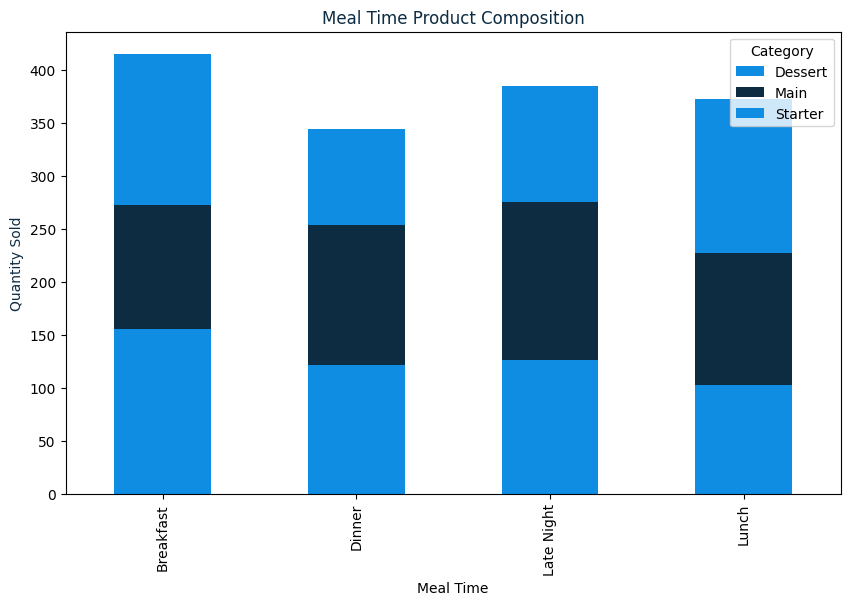

In [15]:
mix = df.groupby(["Meal Time", "Category"])["Quantity"].sum().unstack()
mix.plot(kind="bar", stacked=True, figsize=(10,6), color=[colors["accent_blue"], colors["dark_blue"]])
plt.title("Meal Time Product Composition", color=colors["dark_blue"])
plt.ylabel("Quantity Sold", color=colors["dark_blue"])
plt.show()


This chart presents the percentage distribution of product categories sold across different meal times—Breakfast, Lunch, Dinner, and Late Night. A key observation is the dominance of main courses, which constitute the largest share of sales throughout all meal periods. Particularly during Dinner and Late Night, main courses account for close to 40% of total sales, underscoring their strong appeal to customers during these times. In contrast, Starters are most frequently sold during Breakfast, indicating a preference for lighter or introductory dishes in the early part of the day. Overall, the consistent prominence of main courses across every meal time reflects their central role in the menu and highlights opportunities to tailor promotional and operational strategies by meal period to maximize revenue.

# Customer Payment Method Preferences #

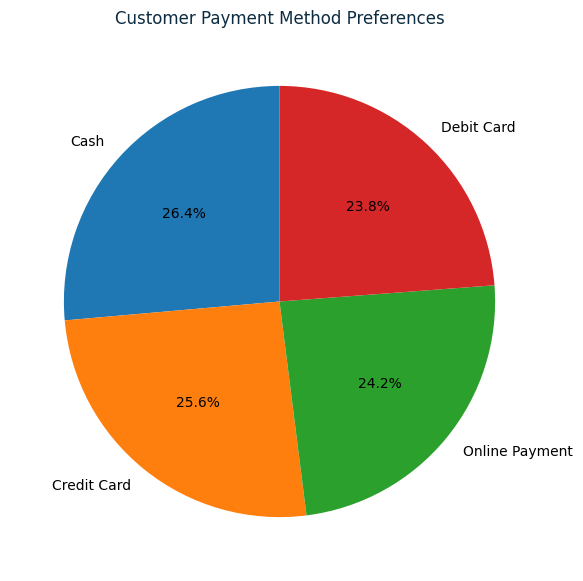

In [16]:
pay = df["Payment Method"].value_counts()
plt.figure(figsize=(7,7))
plt.pie(pay, labels=pay.index, autopct="%1.1f%%", startangle=90)
plt.title("Customer Payment Method Preferences", color=colors["dark_blue"])
plt.show()

This pie chart illustrates the percentage distribution of payment methods utilized by customers. The data reveals that cash remains the preferred payment method, accounting for 26.4% of transactions. However, other payment methods—credit card (25.6%), online payment (24.2%), and debit card (23.8%)—are utilized at nearly equivalent rates. This near-equal distribution suggests a balanced spread of income sources across multiple payment channels, reflecting the business’s adaptability to diverse customer preferences. The predominance of cash highlights its continued relevance, while the substantial usage of electronic and card payments underscores the importance of offering multiple payment options to cater to varied customer needs and enhance transaction convenience.

# Menu Optimization Matrix #

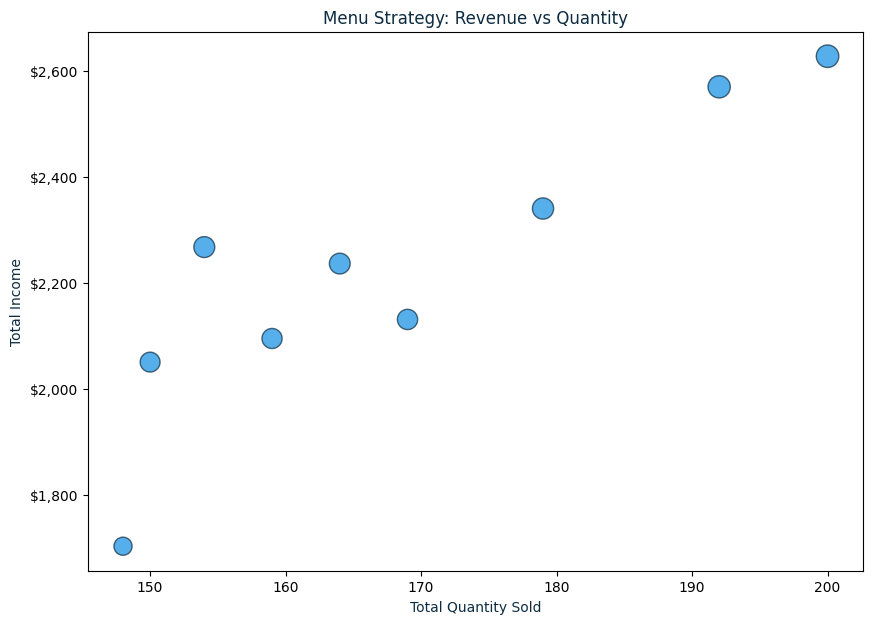

In [17]:
summary = df.groupby("Food Item").agg({"Quantity":"sum", "Income":"sum"})
plt.figure(figsize=(10,7))
plt.scatter(summary["Quantity"], summary["Income"], s=summary["Income"]/10, color=colors["accent_blue"], alpha=0.7, edgecolor=colors["dark_blue"])
plt.title("Menu Strategy: Revenue vs Quantity", color=colors["dark_blue"])
plt.xlabel("Total Quantity Sold", color=colors["dark_blue"])
plt.ylabel("Total Income", color=colors["dark_blue"])
plt.gca().yaxis.set_major_formatter(FuncFormatter(currency))
plt.show()

This menu optimization matrix chart visually positions each product based on two key performance metrics: total quantity sold and total income generated. The chart segments items into four distinct categories, facilitating strategic decision-making.

* Champions: Pizza and Brownie occupy the top-right matrix, representing the products that excel in both sales volume and revenue generation. These flagship items are crucial drivers of profitability and should be prioritized in menu positioning and promotion.

* Profit Drivers: This matrix, which represents items with below-average sales volume but above-average income, is notably unoccupied in this analysis. The absence of profit drivers suggests that all high-income items also tend to have robust sales volume.

* Rising Stars: Fries fall into the rising stars quadrant, characterized by high sales volume but average income. This indicates significant customer demand paired with untapped potential for revenue growth through pricing or cost optimization strategies.

* Low Performers:  Ice Cream and Soup are positioned in the bottom-left quadrant, reflecting both lower sales and income. These items may warrant reevaluation regarding their place on the menu, potential recipe modifications, or targeted marketing to boost performance.

This matrix-based approach serves as a critical tool for understanding menu item performance, enabling data-driven strategies to enhance profitability and refine product offerings.


# Recommendations #

Based on the comprehensive data analysis, several strategic initiatives are proposed to enhance both revenue generation and customer satisfaction:

* Mobile Loyalty Incentive Program: The predominance of cash payments highlights a potential gap in customer engagement initiatives. Implementing a QR code-based loyalty program would offer exclusive promotions and rewards, fostering long-term customer loyalty while simultaneously encouraging the adoption of non-cash payment methods. This digital approach not only modernizes the payment experience but also provides valuable data to personalize marketing efforts.

* Weekend & Seasonal Partnership Offers: To address the notable dip in income observed in August and Saturdays, targeted promotions such as "Buy One, Get One Free" or "25% off when bringing a friend" can be implemented. These campaigns aim to stimulate visitation during slower periods by leveraging value-driven offers that incentivize customers to dine together, thereby increasing order volume and overall revenue.

* Targeted Lunchtime Promotions: Given that lunchtime is consistently the busiest period, introducing a fixed-price "Lunch Menu" featuring high-performing "Top Performer" items such as Pizza and Brownie could drive additional traffic and increase sales, particularly on traditionally lower-income days like Monday and Thursday. This approach encourages customer visits during off-peak revenue days, maximizing utilization of busy periods.